# 🌦️Weather Data Dashboard using Matplotlib & Plotly
This project analyzes weather data (2015-2025) for multiple Indian cities.

**Features:**
- Average temperature trends
- Rainfall analysis
- Humidity comparisons
- Static (Matplotlib) & Interactive (Plotly) visualizations


In [11]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import sys


%matplotlib inline

In [12]:
# 2. Load dataset
df = pd.read_csv("weather_data.csv")
print("Rows, Columns:", df.shape)
df.head()

Rows, Columns: (792, 6)


,Year,Month,City,Temperature,Rainfall,Humidity
0,2015,1,Delhi,21.9,78.5,79.1
1,2015,2,Delhi,29.0,23.9,75.4
2,2015,3,Delhi,31.1,3.6,65.5
3,2015,4,Delhi,33.9,51.9,63.7
4,2015,5,Delhi,31.2,57.3,61.2


In [13]:
# 3. Preprocessing
df['Year'] = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)
df['Date'] = pd.to_datetime(df[['Year','Month']].assign(DAY=1))
df.head()

,Year,Month,City,Temperature,Rainfall,Humidity,Date
0,2015,1,Delhi,21.9,78.5,79.1,2015-01-01
1,2015,2,Delhi,29.0,23.9,75.4,2015-02-01
2,2015,3,Delhi,31.1,3.6,65.5,2015-03-01
3,2015,4,Delhi,33.9,51.9,63.7,2015-04-01
4,2015,5,Delhi,31.2,57.3,61.2,2015-05-01


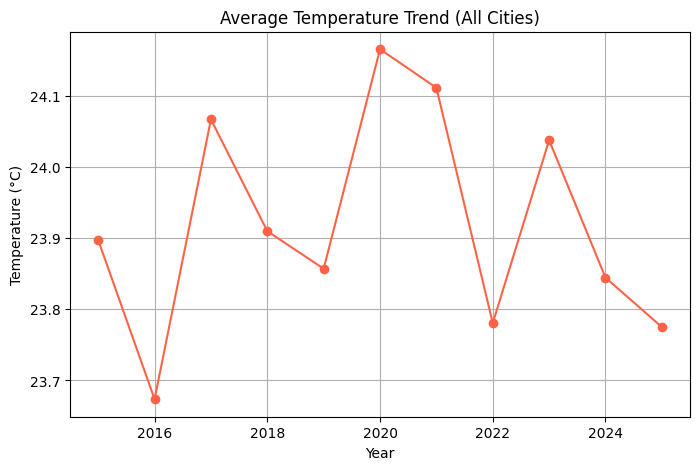

In [14]:
# 4. Matplotlib: Average Temperature Trend
avg_temp = df.groupby('Year')['Temperature'].mean()
plt.figure(figsize=(8,5))
plt.plot(avg_temp.index, avg_temp.values, marker='o', color='tomato')
plt.title("Average Temperature Trend (All Cities)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

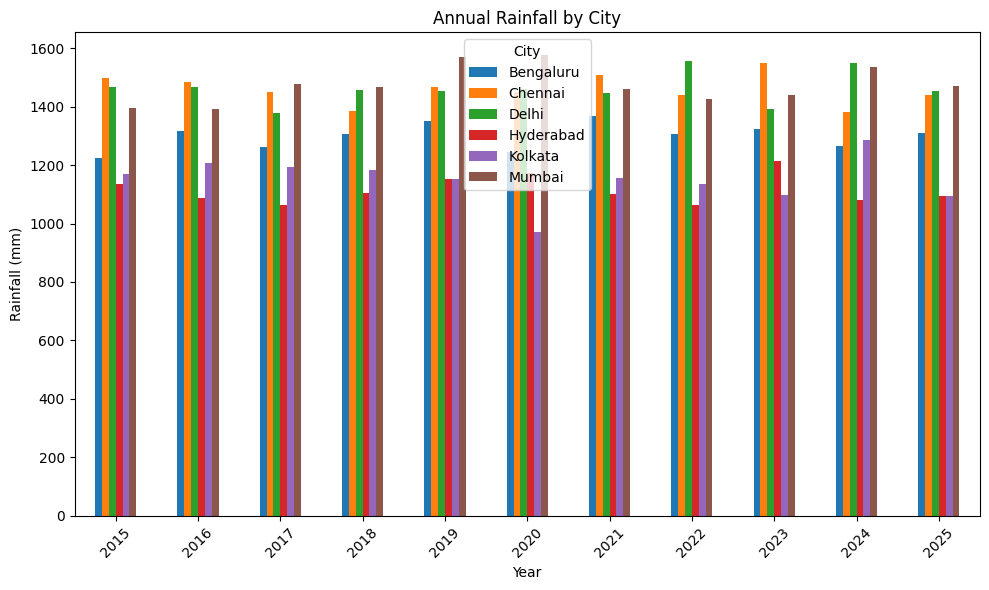

In [15]:
# 5. Matplotlib: Annual Rainfall by City
annual_rain = df.groupby(['Year','City'])['Rainfall'].sum().reset_index()
rain_pivot = annual_rain.pivot(index='Year', columns='City', values='Rainfall')

rain_pivot.plot(kind='bar', stacked=False, figsize=(10,6))
plt.title("Annual Rainfall by City")
plt.ylabel("Rainfall (mm)")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

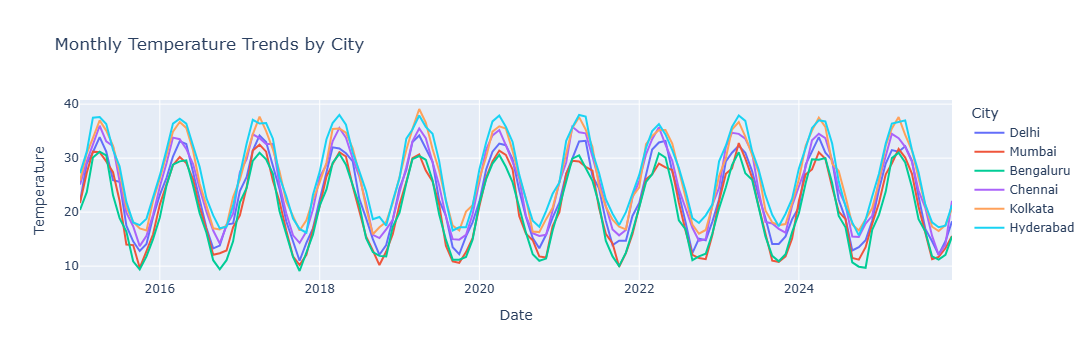

In [16]:
# 6. Plotly: Temperature Trends by City
fig = px.line(df, x='Date', y='Temperature', color='City',
              title="Monthly Temperature Trends by City")
fig.show()

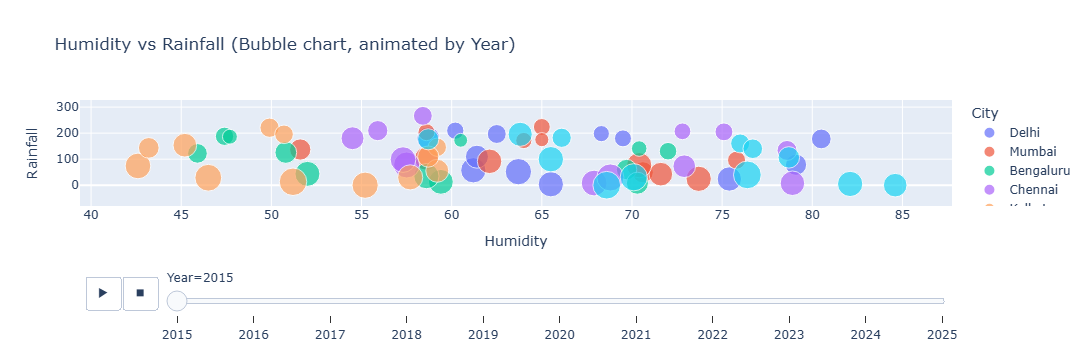

In [17]:
# 7. Plotly: Humidity vs Rainfall (Interactive Scatter)
fig = px.scatter(df, x='Humidity', y='Rainfall', color='City',
                 animation_frame='Year', size='Temperature',
                 title="Humidity vs Rainfall (Bubble chart, animated by Year)")
fig.show()

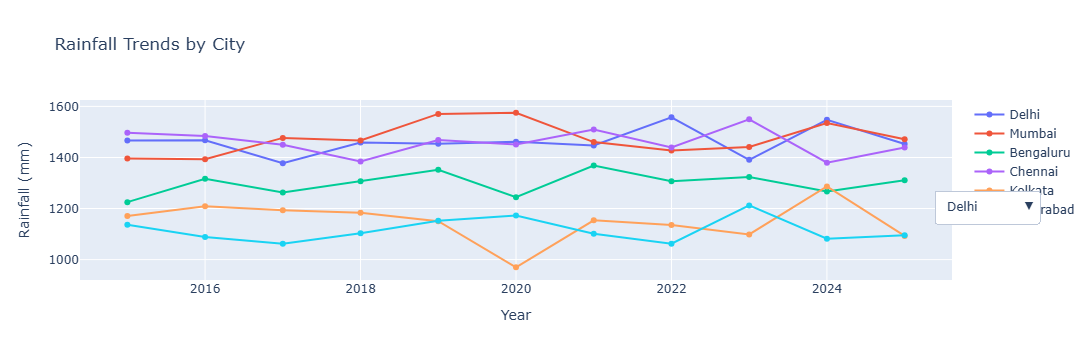

In [18]:
# 8. Plotly: Rainfall with Dropdown by City
cities = df['City'].unique()
fig = go.Figure()

for city in cities:
    city_df = df[df['City'] == city].groupby('Year')['Rainfall'].sum().reset_index()
    fig.add_trace(go.Scatter(x=city_df['Year'], y=city_df['Rainfall'],
                             mode='lines+markers', name=city, visible=True))

fig.update_layout(
    title="Rainfall Trends by City",
    xaxis_title="Year",
    yaxis_title="Rainfall (mm)",
    updatemenus=[{
        "buttons": [
            {"label": city, "method": "update",
             "args": [{"visible": [c==city for c in cities]},
                      {"title": f"Rainfall in {city}"}]}
            for city in cities
        ],
        "direction": "down",
        "x": 1.1, "y": 0.5
    }]
)

fig.show()

Future Predictions (2026–2030):


,Year,Temperature,Rainfall,Humidity
0,2026,23.918763,8008.940000,63.773157
1,2027,23.918586,8017.434545,63.792588
2,2028,23.918409,8025.929091,63.812020
3,2029,23.918232,8034.423636,63.831452
4,2030,23.918056,8042.918182,63.850884


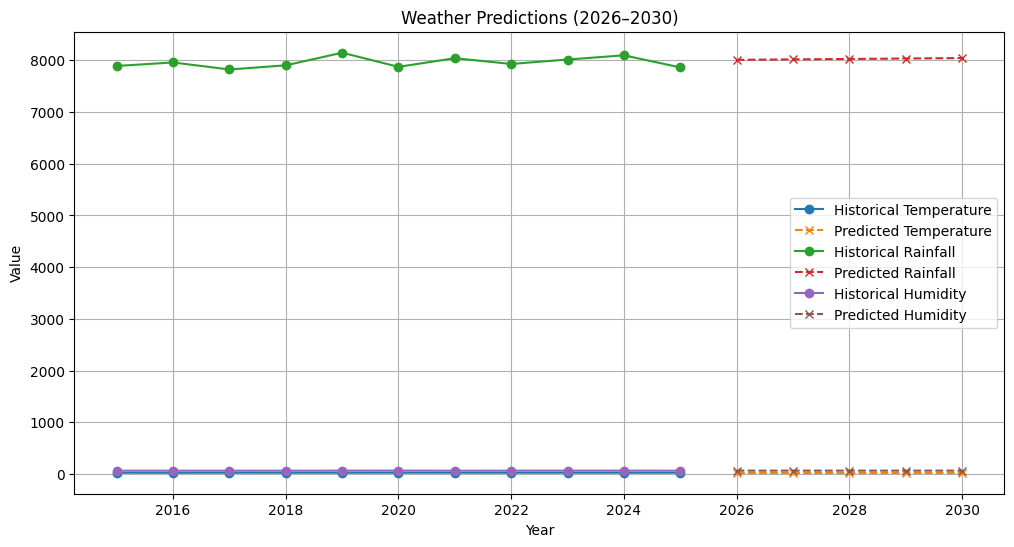

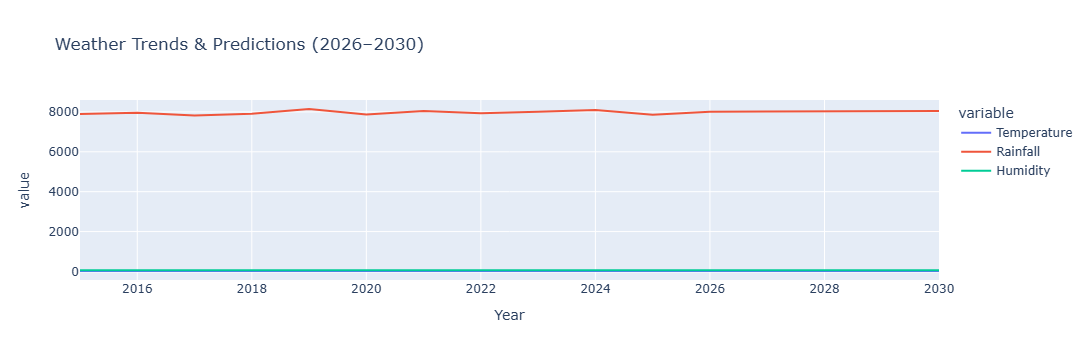

In [19]:
# 9. Predicting Future Weather (Temperature, Rainfall, Humidity)

from sklearn.linear_model import LinearRegression
import numpy as np

# Aggregate yearly averages/sums
yearly_data = df.groupby('Year').agg({
    'Temperature': 'mean',
    'Rainfall': 'sum',
    'Humidity': 'mean'
}).reset_index()

# Prepare features
X = yearly_data['Year'].values.reshape(-1, 1)

# Predict for future years (2026–2030)
future_years = np.arange(2026, 2031).reshape(-1, 1)

predictions = {}

for col in ['Temperature', 'Rainfall', 'Humidity']:
    model = LinearRegression()
    model.fit(X, yearly_data[col])
    preds = model.predict(future_years)
    predictions[col] = preds

# Create future dataframe
future_df = pd.DataFrame({
    'Year': future_years.flatten(),
    'Temperature': predictions['Temperature'],
    'Rainfall': predictions['Rainfall'],
    'Humidity': predictions['Humidity']
})

print("Future Predictions (2026–2030):")
display(future_df)

# Visualization
plt.figure(figsize=(12,6))

for col, ylabel in zip(['Temperature','Rainfall','Humidity'],
                       ['Temperature (°C)','Rainfall (mm)','Humidity (%)']):
    plt.plot(yearly_data['Year'], yearly_data[col], marker='o', label=f"Historical {col}")
    plt.plot(future_df['Year'], future_df[col], marker='x', linestyle='--', label=f"Predicted {col}")

plt.title("Weather Predictions (2026–2030)")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

# Interactive version (Plotly)
fig = px.line(pd.concat([yearly_data, future_df]), x='Year', y=['Temperature','Rainfall','Humidity'],
              title="Weather Trends & Predictions (2026–2030)")
fig.show()


Enter Year (e.g., 2020):  2021
Enter City (e.g., Delhi):  Hyderabad


,Month,Temperature,Rainfall,Humidity
732,1,25.5,58.1,79.0
733,2,33.2,4.0,78.5
734,3,35.7,4.0,78.0
735,4,38.0,43.2,68.0
736,5,37.7,42.4,65.0
737,6,31.1,86.5,66.8
738,7,27.3,170.5,58.3
739,8,22.4,151.9,65.1
740,9,19.7,181.9,59.8
741,10,17.6,185.6,73.9


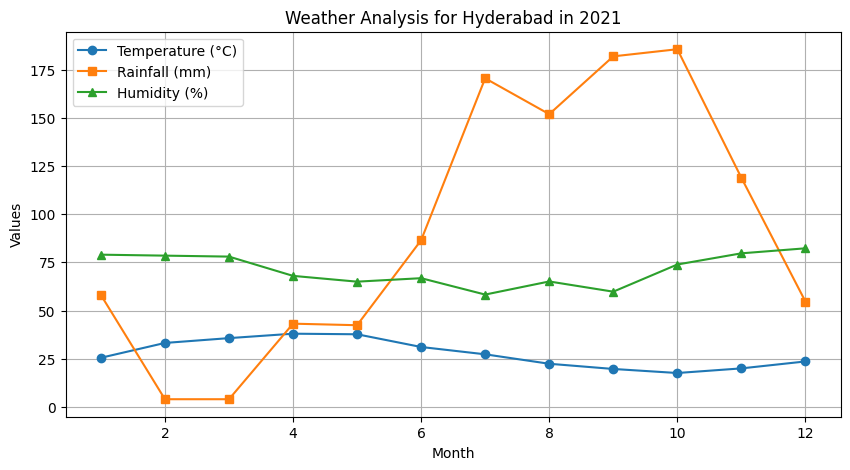

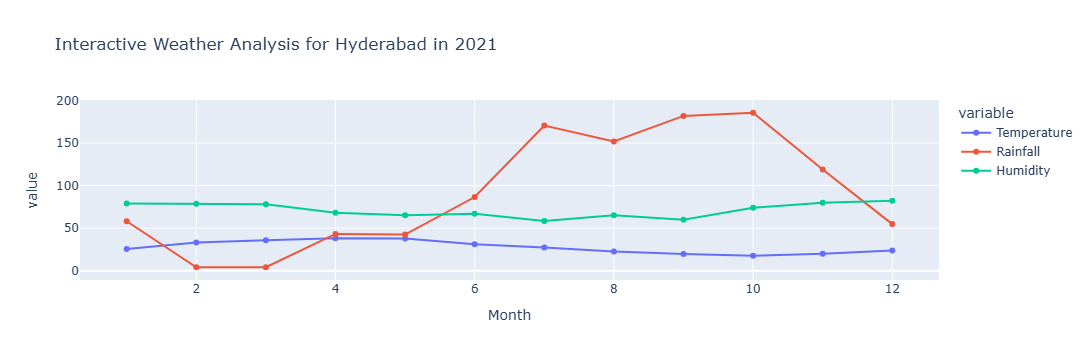

In [20]:
# 10. Year & City-wise Analysis (Table + Visualization)

# Take user input
year_input = int(input("Enter Year (e.g., 2020): "))
city_input = input("Enter City (e.g., Delhi): ").strip()

# Filter dataset
subset = df[(df['Year'] == year_input) & (df['City'].str.lower() == city_input.lower())]

if subset.empty:
    print(f"No data found for {city_input} in {year_input}")
else:
    # Display table (Humidity, Rainfall, Temperature by Month)
    display(subset[['Month', 'Temperature', 'Rainfall', 'Humidity']])

    # Visualization with Matplotlib
    plt.figure(figsize=(10,5))
    plt.plot(subset['Month'], subset['Temperature'], marker='o', label='Temperature (°C)')
    plt.plot(subset['Month'], subset['Rainfall'], marker='s', label='Rainfall (mm)')
    plt.plot(subset['Month'], subset['Humidity'], marker='^', label='Humidity (%)')
    plt.title(f"Weather Analysis for {city_input} in {year_input}")
    plt.xlabel("Month")
    plt.ylabel("Values")
    plt.legend()
    plt.grid(True)  
    plt.show()

    # Visualization with Plotly (interactive)
    fig = px.line(subset, x='Month', y=['Temperature','Rainfall','Humidity'],
                  markers=True, title=f"Interactive Weather Analysis for {city_input} in {year_input}")
    fig.show()
